In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


data_path = Path(
    "../data/processed/"
    "eia_tx_retail_prices_long.csv"
)

df = pd.read_csv(
    data_path,
    parse_dates=["period"],
)

df.head()

,period,stateid,stateDescription,sectorid,sectorName,price,price-units
0,2015-01-01,TX,Texas,COM,commercial,8.40,cents per kilowatt-hour
1,2015-01-01,TX,Texas,IND,industrial,5.93,cents per kilowatt-hour
2,2015-01-01,TX,Texas,RES,residential,11.49,cents per kilowatt-hour
3,2015-02-01,TX,Texas,COM,commercial,8.50,cents per kilowatt-hour
4,2015-02-01,TX,Texas,IND,industrial,5.84,cents per kilowatt-hour


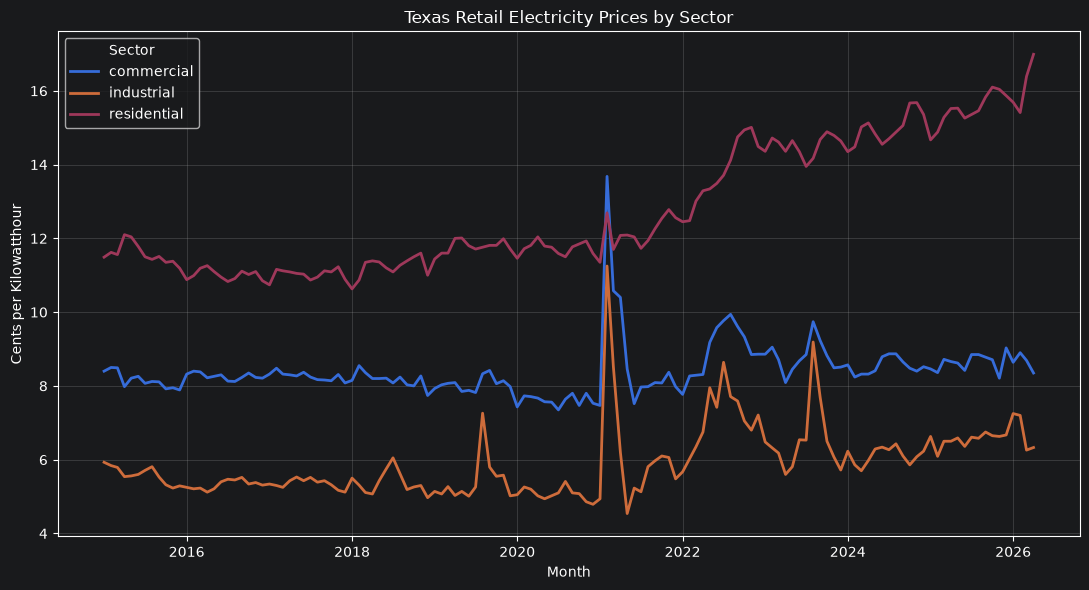

In [2]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for sector_name, group in df.groupby(
    "sectorName"
):
    ax.plot(
        group["period"],
        group["price"],
        label=sector_name,
        linewidth=2,
    )

ax.set_title(
    "Texas Retail Electricity Prices by Sector"
)

ax.set_xlabel("Month")

ax.set_ylabel(
    "Cents per Kilowatthour"
)

ax.legend(
    title="Sector"
)

ax.grid(alpha=0.3)

fig.tight_layout()

figure_path = Path(
    "../reports/figures/"
    "tx_retail_prices_by_sector.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()